# Setting Configuration

In [1]:
# PySpark API:
#http://spark.apache.org/docs/latest/api/python/index.html

import os
import sys
 
os.environ["SPARK_HOME"] = "/usr/spark2.4.3"
os.environ["PYLIB"] = os.environ["SPARK_HOME"] + "/python/lib"
# In below two lines, use /usr/bin/python2.7 if you want to use Python 2
os.environ["PYSPARK_PYTHON"] = "/usr/local/anaconda/bin/python" 
os.environ["PYSPARK_DRIVER_PYTHON"] = "/usr/local/anaconda/bin/python"
sys.path.insert(0, os.environ["PYLIB"] +"/py4j-0.10.7-src.zip")
sys.path.insert(0, os.environ["PYLIB"] +"/pyspark.zip")

#import and define spark context
from pyspark import SparkContext, SparkConf
conf = SparkConf().setAppName("appName2")
sc = SparkContext(conf=conf)

#from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, HiveContext
from pyspark.sql.types import *
#sc= SparkContext()
sqlContext = SQLContext(sc)

#get python and spark versions
import platform
print(platform.python_version())
print(sc.version)

#import python sql libraries and other functions
from pyspark.sql.types import *
from pyspark.sql import Row
from pyspark.sql.functions import *

# import python library for plotting data
import matplotlib.pyplot as plt
import gmplot

#import pandas and numpy
import pandas as pd
#import numpy as np

3.6.8
2.4.3


In [2]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SQLContext

from pyspark.sql import SparkSession
from functools import reduce
from pyspark.sql.functions import col, lit, when
#from graphframes import *


spark = SparkSession.builder.appName("Accidents").config("spark.jars.packages", "graphframes:graphframes:0.6.0-spark2.3-s_2.11").enableHiveSupport().getOrCreate()

sqlContext = SQLContext(spark)

# Create "Accidents and Vehicle" DataFrame

In [3]:
accidents = spark.read.option("header", "true").option("delimiter",",")\
.option("inferschema","true").csv("hdfs:///user/imat5322_915567/*road-accidents.csv")

In [4]:
accidents

DataFrame[accident_index: string, accident_year: int, accident_reference: string, location_easting_osgr: string, location_northing_osgr: string, longitude: string, latitude: string, police_force: int, accident_severity: int, number_of_vehicles: int, number_of_casualties: int, date: string, day_of_week: int, time: string, local_authority_district: int, local_authority_ons_district: string, local_authority_highway: string, first_road_class: int, first_road_number: int, road_type: int, speed_limit: int, junction_detail: int, junction_control: int, second_road_class: int, second_road_number: int, pedestrian_crossing_human_control: int, pedestrian_crossing_physical_facilities: int, light_conditions: int, weather_conditions: int, road_surface_conditions: int, special_conditions_at_site: int, carriageway_hazards: int, urban_or_rural_area: int, did_police_officer_attend_scene_of_accident: int, trunk_road_flag: int, lsoa_of_accident_location: string]

In [5]:
accidents.printSchema()

root
 |-- accident_index: string (nullable = true)
 |-- accident_year: integer (nullable = true)
 |-- accident_reference: string (nullable = true)
 |-- location_easting_osgr: string (nullable = true)
 |-- location_northing_osgr: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- police_force: integer (nullable = true)
 |-- accident_severity: integer (nullable = true)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: string (nullable = true)
 |-- local_authority_district: integer (nullable = true)
 |-- local_authority_ons_district: string (nullable = true)
 |-- local_authority_highway: string (nullable = true)
 |-- first_road_class: integer (nullable = true)
 |-- first_road_number: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable =

In [6]:
vehicle = spark.read.option("header", "true").option("delimiter",",")\
.option("inferschema","true").csv("hdfs:///user/imat5322_915567/*road-vehicle.csv")

In [7]:
vehicle

DataFrame[accident_index: string, accident_year: int, accident_reference: string, vehicle_reference: int, vehicle_type: int, towing_and_articulation: int, vehicle_manoeuvre: int, vehicle_direction_from: int, vehicle_direction_to: int, vehicle_location_restricted_lane: int, junction_location: int, skidding_and_overturning: int, hit_object_in_carriageway: int, vehicle_leaving_carriageway: int, hit_object_off_carriageway: int, first_point_of_impact: int, vehicle_left_hand_drive: int, journey_purpose_of_driver: int, sex_of_driver: int, age_of_driver: int, age_band_of_driver: int, engine_capacity_cc: int, propulsion_code: int, age_of_vehicle: int, generic_make_model: string, driver_imd_decile: int, driver_home_area_type: int]

In [8]:
Veh = vehicle.drop('accident_year')

In [9]:
Veh.printSchema()

root
 |-- accident_index: string (nullable = true)
 |-- accident_reference: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- vehicle_type: integer (nullable = true)
 |-- towing_and_articulation: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- vehicle_direction_from: integer (nullable = true)
 |-- vehicle_direction_to: integer (nullable = true)
 |-- vehicle_location_restricted_lane: integer (nullable = true)
 |-- junction_location: integer (nullable = true)
 |-- skidding_and_overturning: integer (nullable = true)
 |-- hit_object_in_carriageway: integer (nullable = true)
 |-- vehicle_leaving_carriageway: integer (nullable = true)
 |-- hit_object_off_carriageway: integer (nullable = true)
 |-- first_point_of_impact: integer (nullable = true)
 |-- vehicle_left_hand_drive: integer (nullable = true)
 |-- journey_purpose_of_driver: integer (nullable = true)
 |-- sex_of_driver: integer (nullable = true)
 |-- age_of_driver: integer

# Combining The Accident Dataframe And Vehicle Dataframe

In [10]:
combinedf = accidents.join(Veh, accidents.\
accident_index == Veh.accident_index)

In [11]:
combinedf.printSchema()

root
 |-- accident_index: string (nullable = true)
 |-- accident_year: integer (nullable = true)
 |-- accident_reference: string (nullable = true)
 |-- location_easting_osgr: string (nullable = true)
 |-- location_northing_osgr: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- police_force: integer (nullable = true)
 |-- accident_severity: integer (nullable = true)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: string (nullable = true)
 |-- local_authority_district: integer (nullable = true)
 |-- local_authority_ons_district: string (nullable = true)
 |-- local_authority_highway: string (nullable = true)
 |-- first_road_class: integer (nullable = true)
 |-- first_road_number: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable =

# Data Preparation and Cleaning

In [12]:
#Dropping unrequired fields
AccVeh = combinedf.drop("accident_index", "accident_reference", "location_easting_osgr", "location_northing_osgr",\
                       "time", "local_authority_ons_district", "local_authority_highway", "first_road_class",\
                       "first_road_number", "junction_detail", "junction_control", "second_road_class",\
                    "second_road_number", "pedestrian_crossing_human_control", "pedestrian_crossing_physical_facilities",\
                    "special_conditions_at_site", "carriageway_hazards", "trunk_road_flag", "lsoa_of_accident_location",\
                    "vehicle_reference", "towing_and_articulation", "vehicle_manoeuvre", "vehicle_direction_from",\
                    "vehicle_direction_to", "vehicle_location_restricted_lane", "junction_location",\
                    "skidding_and_overturning", "hit_object_in_carriageway", "vehicle_leaving_carriageway",\
                    "hit_object_off_carriageway", "first_point_of_impact", "vehicle_left_hand_drive", "age_of_driver",\
                    "engine_capacity_cc", "propulsion_code", "age_of_vehicle", "generic_make_model",\
                    "driver_imd_decile", "local_authority_district", "driver_home_area_type", "vehicle_type")

In [13]:
AccVeh.printSchema()

root
 |-- accident_year: integer (nullable = true)
 |-- longitude: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- police_force: integer (nullable = true)
 |-- accident_severity: integer (nullable = true)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)
 |-- did_police_officer_attend_scene_of_accident: integer (nullable = true)
 |-- journey_purpose_of_driver: integer (nullable = true)
 |-- sex_of_driver: integer (nullable = true)
 |-- age_band_of_driver: integer (nullable = true)



# Renaming The Values From Numbers to Meaningful Words

In [14]:
#changing value labels from numbers to meaningful words using regexp_replace
AccVeh_data = AccVeh.withColumn('Day_of_Week', regexp_replace('Day_of_Week', '1', 'Sunday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '2', 'Monday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '3', 'Tuesday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '4', 'Wednesday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '5', 'Thursday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '6', 'Friday'))\
.withColumn('day_of_week', regexp_replace('day_of_week', '7', 'Saturday'))\
.withColumn('road_type', when(AccVeh.road_type == "1", regexp_replace(AccVeh.\
road_type, "1", "Roundabout")).\
when(AccVeh.road_type == "2", regexp_replace(AccVeh.road_type, "2", "One way street")).\
when(AccVeh.road_type == "3", regexp_replace(AccVeh.road_type, "3", "Dual carriageway")).\
when(AccVeh.road_type == "6", regexp_replace(AccVeh.road_type, "6", "Single carriageway")).\
when(AccVeh.road_type == "7", regexp_replace(AccVeh.road_type, "7", "Slip road")).\
when(AccVeh.road_type == "9", regexp_replace(AccVeh.road_type, "9", "Unknown")).\
when(AccVeh.road_type == "12", regexp_replace(AccVeh.road_type, "12", "One way street/Slip road")).\
when(AccVeh.road_type == "-1", regexp_replace(AccVeh.\
road_type, "-1", "Data missing or out of range")).otherwise(AccVeh.road_type))\
.withColumn('light_conditions', when(AccVeh.light_conditions == "1", regexp_replace(AccVeh.\
light_conditions, "1", "Daylight")).\
when(AccVeh.light_conditions == "4", regexp_replace(AccVeh.light_conditions, "4", "Darkness - lights lit")).\
when(AccVeh.light_conditions == "5", regexp_replace(AccVeh.light_conditions, "5", "Darkness - lights unlit")).\
when(AccVeh.light_conditions == "6", regexp_replace(AccVeh.light_conditions, "6", "Darkness - no lighting")).\
when(AccVeh.light_conditions == "7", regexp_replace(AccVeh.light_conditions, "7", "Darkness - lighting unknown")).\
when(AccVeh.light_conditions == "-1", regexp_replace(AccVeh.\
light_conditions, "-1", "Data missing or out of range")).otherwise(AccVeh.light_conditions))\
.withColumn('weather_conditions', when(AccVeh.weather_conditions == "1", regexp_replace(AccVeh.\
weather_conditions, "1", "Fine no high winds")).\
when(AccVeh.weather_conditions == "2", regexp_replace(AccVeh.weather_conditions, "2", "Raining no high winds")).\
when(AccVeh.weather_conditions == "3", regexp_replace(AccVeh.weather_conditions, "3", "Snowing no high winds")).\
when(AccVeh.weather_conditions == "4", regexp_replace(AccVeh.weather_conditions, "4", "Fine + high winds")).\
when(AccVeh.weather_conditions == "5", regexp_replace(AccVeh.weather_conditions, "5", "Raining + high winds")).\
when(AccVeh.weather_conditions == "6", regexp_replace(AccVeh.weather_conditions, "6", "Snowing + high winds")).\
when(AccVeh.weather_conditions == "7", regexp_replace(AccVeh.weather_conditions, "7", "Fog or mist")).\
when(AccVeh.weather_conditions == "8", regexp_replace(AccVeh.weather_conditions, "8", "Other")).\
when(AccVeh.weather_conditions == "9", regexp_replace(AccVeh.weather_conditions, "9", "Unknown")).\
when(AccVeh.weather_conditions == "-1", regexp_replace(AccVeh.\
weather_conditions, "-1", "Data missing or out of range")).otherwise(AccVeh.weather_conditions))\
.withColumn('road_surface_conditions', when(AccVeh.road_surface_conditions == "1", regexp_replace(AccVeh.\
road_surface_conditions, "1", "Dry")).\
when(AccVeh.road_surface_conditions == "2", regexp_replace(AccVeh.road_surface_conditions, "2", "Wet or damp")).\
when(AccVeh.road_surface_conditions == "3", regexp_replace(AccVeh.road_surface_conditions, "3", "Snow")).\
when(AccVeh.road_surface_conditions == "4", regexp_replace(AccVeh.road_surface_conditions, "4", "Frost or ice")).\
when(AccVeh.road_surface_conditions == "5", regexp_replace(AccVeh.road_surface_conditions, "5", "Flood over 3cm. deep")).\
when(AccVeh.road_surface_conditions == "6", regexp_replace(AccVeh.road_surface_conditions, "6", "Oil or diesel")).\
when(AccVeh.road_surface_conditions == "7", regexp_replace(AccVeh.road_surface_conditions, "7", "Mud")).\
when(AccVeh.road_surface_conditions == "9", regexp_replace(AccVeh.road_surface_conditions, "9", "unknown (self reported)")).\
when(AccVeh.road_surface_conditions == "-1", regexp_replace(AccVeh.\
road_surface_conditions, "-1", "Data missing or out of range")).otherwise(AccVeh.road_surface_conditions))\
.withColumn('Accident_Severity', regexp_replace('Accident_Severity', '1', 'Fatal'))\
.withColumn('Accident_Severity', regexp_replace('Accident_Severity', '2', 'Serious'))\
.withColumn('Accident_Severity', regexp_replace('Accident_Severity', '3', 'Slight'))\
.withColumn('sex_of_driver', when(AccVeh.sex_of_driver == "1", regexp_replace(AccVeh.\
sex_of_driver, "1", "Male")).\
when(AccVeh.sex_of_driver == "2", regexp_replace(AccVeh.sex_of_driver, "2", "Female")).\
when(AccVeh.sex_of_driver == "3", regexp_replace(AccVeh.sex_of_driver, "3", "Not known")).\
when(AccVeh.sex_of_driver == "-1", regexp_replace(AccVeh.\
sex_of_driver, "-1", "Data missing or out of range")).otherwise(AccVeh.sex_of_driver))\
.withColumn('did_police_officer_attend_scene_of_accident', when(AccVeh.did_police_officer_attend_scene_of_accident == "1", regexp_replace(AccVeh.\
did_police_officer_attend_scene_of_accident, "1", "Yes")).\
when(AccVeh.did_police_officer_attend_scene_of_accident == "2", regexp_replace(AccVeh.\
did_police_officer_attend_scene_of_accident, "2", "No")).\
when(AccVeh.did_police_officer_attend_scene_of_accident == "3", regexp_replace(AccVeh.\
did_police_officer_attend_scene_of_accident, "3", "No - accident was reported (self rep only)")).\
when(AccVeh.did_police_officer_attend_scene_of_accident == "-1", regexp_replace(AccVeh.\
did_police_officer_attend_scene_of_accident, "-1", "Data missing or out of range")).otherwise(AccVeh.did_police_officer_attend_scene_of_accident))\
.withColumn('journey_purpose_of_driver', when(AccVeh.journey_purpose_of_driver == "1", regexp_replace(AccVeh.\
journey_purpose_of_driver, "1", "Journey as part of work")).\
when(AccVeh.journey_purpose_of_driver == "2", regexp_replace(AccVeh.journey_purpose_of_driver, "2", "Commuting to/from work")).\
when(AccVeh.journey_purpose_of_driver == "3", regexp_replace(AccVeh.journey_purpose_of_driver, "3", "Taking pupil to/from school")).\
when(AccVeh.journey_purpose_of_driver == "4", regexp_replace(AccVeh.journey_purpose_of_driver, "4", "Pupil riding to/from school")).\
when(AccVeh.journey_purpose_of_driver == "5", regexp_replace(AccVeh.journey_purpose_of_driver, "5", "Other")).\
when(AccVeh.journey_purpose_of_driver == "6", regexp_replace(AccVeh.journey_purpose_of_driver, "6", "Not known")).\
when(AccVeh.journey_purpose_of_driver == "-1", regexp_replace(AccVeh.\
journey_purpose_of_driver, "-1", "Data missing or out of range")).otherwise(AccVeh.journey_purpose_of_driver))\
.withColumn('age_band_of_driver', when(AccVeh.age_band_of_driver == "1", regexp_replace(AccVeh.\
age_band_of_driver, "1", "0-5")).\
when(AccVeh.age_band_of_driver == "2", regexp_replace(AccVeh.age_band_of_driver, "2", "6-10")).\
when(AccVeh.age_band_of_driver == "3", regexp_replace(AccVeh.age_band_of_driver, "3", "11-15")).\
when(AccVeh.age_band_of_driver == "4", regexp_replace(AccVeh.age_band_of_driver, "4", "16-20")).\
when(AccVeh.age_band_of_driver == "5", regexp_replace(AccVeh.age_band_of_driver, "5", "21-25")).\
when(AccVeh.age_band_of_driver == "6", regexp_replace(AccVeh.age_band_of_driver, "6", "26-35")).\
when(AccVeh.age_band_of_driver == "7", regexp_replace(AccVeh.age_band_of_driver, "7", "36-45")).\
when(AccVeh.age_band_of_driver == "8", regexp_replace(AccVeh.age_band_of_driver, "8", "46-55")).\
when(AccVeh.age_band_of_driver == "9", regexp_replace(AccVeh.age_band_of_driver, "9", "56-65")).\
when(AccVeh.age_band_of_driver == "10", regexp_replace(AccVeh.age_band_of_driver, "10", "66-75")).\
when(AccVeh.age_band_of_driver == "11", regexp_replace(AccVeh.age_band_of_driver, "11", "Over 75")).\
when(AccVeh.age_band_of_driver == "-1", regexp_replace(AccVeh.\
age_band_of_driver, "-1", "Data missing or out of range")).otherwise(AccVeh.age_band_of_driver))\
.withColumn('urban_or_rural_area', when(AccVeh.urban_or_rural_area == "1", regexp_replace(AccVeh.\
urban_or_rural_area, "1", "Urban")).\
when(AccVeh.urban_or_rural_area == "2", regexp_replace(AccVeh.urban_or_rural_area, "2", "Rural")).\
when(AccVeh.urban_or_rural_area == "3", regexp_replace(AccVeh.urban_or_rural_area, "3", "Unallocated")).\
when(AccVeh.urban_or_rural_area == "-1", regexp_replace(AccVeh.\
urban_or_rural_area, "-1", "null")).otherwise(AccVeh.urban_or_rural_area))


In [15]:
AccVeh_data.take(5)

[Row(accident_year=2018, longitude='0.02788', latitude='51.575585', police_force=1, Accident_Severity='Slight', number_of_vehicles=1, number_of_casualties=1, date='11/01/2018', day_of_week='Thursday', road_type='Single carriageway', speed_limit=30, light_conditions='Daylight', weather_conditions='Fine no high winds', road_surface_conditions='Wet or damp', urban_or_rural_area='Urban', did_police_officer_attend_scene_of_accident='Yes', journey_purpose_of_driver='Not known', sex_of_driver='Male', age_band_of_driver='26-35'),
 Row(accident_year=2018, longitude='-0.109931', latitude='51.548121', police_force=1, Accident_Severity='Slight', number_of_vehicles=1, number_of_casualties=1, date='13/01/2018', day_of_week='Saturday', road_type='Single carriageway', speed_limit=20, light_conditions='Daylight', weather_conditions='Fine no high winds', road_surface_conditions='Dry', urban_or_rural_area='Urban', did_police_officer_attend_scene_of_accident='Yes', journey_purpose_of_driver='Not known', s

In [16]:
AccVeh_data.show()

+-------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+------------------+-----------+--------------------+--------------------+-----------------------+-------------------+-------------------------------------------+-------------------------+-------------+--------------------+
|accident_year|longitude| latitude|police_force|Accident_Severity|number_of_vehicles|number_of_casualties|      date|day_of_week|         road_type|speed_limit|    light_conditions|  weather_conditions|road_surface_conditions|urban_or_rural_area|did_police_officer_attend_scene_of_accident|journey_purpose_of_driver|sex_of_driver|  age_band_of_driver|
+-------------+---------+---------+------------+-----------------+------------------+--------------------+----------+-----------+------------------+-----------+--------------------+--------------------+-----------------------+-------------------+-------------------------------------------+------

In [17]:
i = 0 # reset counter
#get the total records amount
total = AccVeh_data.count()

print("Total Records = " + str(total))

#print the amount of coumns
print("Total columns = " + str(len(AccVeh_data.columns)))
print("------------------------------------------")

#loop entire table and get the missing value number and missing rate of each column
while i < len(AccVeh_data.columns): #loop through all columns
    print(str(i+1) + "." + str(AccVeh_data[i]))
    print("  Missing Values = ") 
    print("------------------------------------------")
    mv = AccVeh_data.select([count(when(AccVeh_data[i].isNull(),\
                                        True))]).show() #check for missing values
    i = i+1 #counter add 1

Total Records = 610165
Total columns = 19
------------------------------------------
1.Column<b'accident_year'>
  Missing Values = 
------------------------------------------
+------------------------------------------------------+
|count(CASE WHEN (accident_year IS NULL) THEN true END)|
+------------------------------------------------------+
|                                                     0|
+------------------------------------------------------+

2.Column<b'longitude'>
  Missing Values = 
------------------------------------------
+--------------------------------------------------+
|count(CASE WHEN (longitude IS NULL) THEN true END)|
+--------------------------------------------------+
|                                                 0|
+--------------------------------------------------+

3.Column<b'latitude'>
  Missing Values = 
------------------------------------------
+-------------------------------------------------+
|count(CASE WHEN (latitude IS NULL) THEN true END)

In [18]:
#reset counter
i=0

print("------------------------------------------")

#loop each column and get the descriptionof each one
while i < len(AccVeh_data.columns):
    mv = AccVeh_data.where(AccVeh_data[i] =='').count() #get the missing value number of current column
    print(str(i+1) + "." + str(AccVeh_data[i]))
    AccVeh_data.where(AccVeh_data[i] !='').describe(AccVeh_data.columns[i]).show()
    print("------------------------------------------")
    i = i+1 #counter add 1


------------------------------------------
1.Column<b'accident_year'>
+-------+-------------+
|summary|accident_year|
+-------+-------------+
|  count|            0|
|   mean|         null|
| stddev|         null|
|    min|         null|
|    max|         null|
+-------+-------------+

------------------------------------------
2.Column<b'longitude'>
+-------+------------------+
|summary|         longitude|
+-------+------------------+
|  count|            610165|
|   mean|-1.224569673813257|
| stddev|1.3782530312988888|
|    min|         -0.000101|
|    max|              NULL|
+-------+------------------+

------------------------------------------
3.Column<b'latitude'>
+-------+------------------+
|summary|          latitude|
+-------+------------------+
|  count|            610165|
|   mean| 52.38213286110727|
| stddev|1.3419138218216007|
|    min|         49.912362|
|    max|              NULL|
+-------+------------------+

------------------------------------------
4.Column<b'poli

In [19]:
AccVeh_data.select("Light_Conditions").show()

+--------------------+
|    Light_Conditions|
+--------------------+
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lighti...|
|Darkness - lighti...|
|Darkness - lighti...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
|Darkness - lights...|
+--------------------+
only showing top 20 rows



In [20]:
AccVeh_data.select("age_band_of_driver").show()

+--------------------+
|  age_band_of_driver|
+--------------------+
|               26-35|
|               46-55|
|Data missing or o...|
|               36-45|
|               21-25|
|               26-35|
|               26-35|
|               36-45|
|               46-55|
|               56-65|
|               36-45|
|               66-75|
|               26-35|
|               36-45|
|Data missing or o...|
|               66-75|
|               21-25|
|               26-35|
|               26-35|
|               21-25|
+--------------------+
only showing top 20 rows



In [21]:
AccVeh_data.select("weather_conditions").show()

+--------------------+
|  weather_conditions|
+--------------------+
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|Raining no high w...|
|Raining no high w...|
|  Fine no high winds|
|  Fine no high winds|
|Raining + high winds|
|Raining + high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
|  Fine no high winds|
+--------------------+
only showing top 20 rows



# Register the DataFrame as a Table

In [22]:
sqlContext.registerDataFrameAsTable(AccVeh_data, "tableAccVeh")

In [23]:
sqlContext.sql("select * from tableAccVeh").take(5)

[Row(accident_year=2018, longitude='0.02788', latitude='51.575585', police_force=1, Accident_Severity='Slight', number_of_vehicles=1, number_of_casualties=1, date='11/01/2018', day_of_week='Thursday', road_type='Single carriageway', speed_limit=30, light_conditions='Daylight', weather_conditions='Fine no high winds', road_surface_conditions='Wet or damp', urban_or_rural_area='Urban', did_police_officer_attend_scene_of_accident='Yes', journey_purpose_of_driver='Not known', sex_of_driver='Male', age_band_of_driver='26-35'),
 Row(accident_year=2018, longitude='-0.109931', latitude='51.548121', police_force=1, Accident_Severity='Slight', number_of_vehicles=1, number_of_casualties=1, date='13/01/2018', day_of_week='Saturday', road_type='Single carriageway', speed_limit=20, light_conditions='Daylight', weather_conditions='Fine no high winds', road_surface_conditions='Dry', urban_or_rural_area='Urban', did_police_officer_attend_scene_of_accident='Yes', journey_purpose_of_driver='Not known', s

In [24]:
# Total rows returned for Casualties per day of week
sqlContext.sql("select Day_of_Week, Number_of_Casualties, count(*) as Count from tableAccVeh group \
by Day_of_Week, Number_of_Casualties").count()

102

# Data Exploration

In [25]:
# Casualties per day of week
dayofweek = sqlContext.sql("select Day_of_Week, Number_of_Casualties, count(*) as Count from tableAccVeh group \
by Day_of_Week, Number_of_Casualties")

In [26]:
dayofweek.show()

+-----------+--------------------+-----+
|Day_of_Week|Number_of_Casualties|Count|
+-----------+--------------------+-----+
|     Sunday|                   1|49367|
|   Thursday|                   7|   57|
|     Sunday|                  19|    3|
|     Monday|                   8|   33|
|  Wednesday|                   6|  171|
|    Tuesday|                  59|    3|
|     Monday|                   5|  531|
|  Wednesday|                   7|   77|
|     Sunday|                   2|11393|
|  Wednesday|                   9|   11|
|     Sunday|                   5|  607|
|   Saturday|                   6|  318|
|     Sunday|                   8|   67|
|   Thursday|                   8|   33|
|   Saturday|                  10|   13|
|    Tuesday|                  11|   11|
|   Saturday|                   1|58720|
|   Thursday|                  20|    2|
|     Friday|                   6|  228|
|  Wednesday|                   8|   34|
+-----------+--------------------+-----+
only showing top

In [27]:
# number of vehicles on the road per day of week
Numberofvehicles = sqlContext.sql("select Day_of_Week, number_of_vehicles, count(*) as Count from tableAccVeh group \
by Day_of_Week, number_of_vehicles")

In [28]:
Numberofvehicles.show()

+-----------+------------------+-----+
|Day_of_Week|number_of_vehicles|Count|
+-----------+------------------+-----+
|     Sunday|                 1|11607|
|   Thursday|                 7|  210|
|     Monday|                 8|   48|
|  Wednesday|                 6|  438|
|  Wednesday|                 7|  203|
|     Monday|                 5|  970|
|     Sunday|                 2|43696|
|  Wednesday|                 9|   36|
|     Sunday|                 5|  890|
|   Saturday|                 6|  294|
|     Sunday|                 8|   64|
|   Thursday|                 8|  104|
|   Saturday|                10|   10|
|   Saturday|                 1|13712|
|     Friday|                 6|  330|
|  Wednesday|                 8|   72|
|     Monday|                17|   17|
|    Tuesday|                 4| 3176|
|  Wednesday|                16|   16|
|     Sunday|                15|   15|
+-----------+------------------+-----+
only showing top 20 rows



In [29]:
# Return distinct list of Speed Limits

sqlContext.sql("SELECT distinct Speed_Limit FROM tableAccVeh").show()

+-----------+
|Speed_Limit|
+-----------+
|         -1|
|         20|
|         40|
|         50|
|         70|
|         60|
|         30|
+-----------+



In [30]:
#number of accidents that happened each day
Date = sqlContext.sql("SELECT Date, \
                        COUNT(*) \
                        FROM tableAccVeh \
                        GROUP BY Date \
                        ORDER BY Date")

In [31]:
Date.show()

+----------+--------+
|      Date|count(1)|
+----------+--------+
|01/01/2018|     405|
|01/01/2019|     389|
|01/01/2020|     331|
|01/02/2018|     767|
|01/02/2019|     572|
|01/02/2020|     524|
|01/03/2018|     438|
|01/03/2019|     566|
|01/03/2020|     427|
|01/04/2018|     393|
|01/04/2019|     578|
|01/04/2020|     144|
|01/05/2018|     636|
|01/05/2019|     585|
|01/05/2020|     275|
|01/06/2018|     616|
|01/06/2019|     582|
|01/06/2020|     455|
|01/07/2018|     599|
|01/07/2019|     605|
+----------+--------+
only showing top 20 rows



In [32]:
Sex_of_driver = sqlContext.sql("SELECT sex_of_driver, COUNT(*) FROM tableAccVeh GROUP BY sex_of_driver ORDER BY sex_of_driver")

In [33]:
Sex_of_driver.show()

+--------------------+--------+
|       sex_of_driver|count(1)|
+--------------------+--------+
|Data missing or o...|      16|
|              Female|  161437|
|                Male|  384193|
|           Not known|   64519|
+--------------------+--------+



In [34]:
Accident_Severity = sqlContext.sql("SELECT Accident_Severity,COUNT(*) FROM tableAccVeh GROUP BY Accident_Severity ORDER BY Accident_Severity")

In [35]:
Accident_Severity.show()

+-----------------+--------+
|Accident_Severity|count(1)|
+-----------------+--------+
|            Fatal|    8374|
|          Serious|  111704|
|           Slight|  490087|
+-----------------+--------+



In [36]:
# Dataframe to explore severity per month
Severity = sqlContext.sql("select Accident_Severity, substring (Date, 4, 2 ) as Month, count(*) as Count from tableAccVeh group \
by Month, Accident_Severity")

In [37]:
Severity.show()

+-----------------+-----+-----+
|Accident_Severity|Month|Count|
+-----------------+-----+-----+
|            Fatal|   08|  776|
|           Slight|   10|44264|
|            Fatal|   03|  592|
|           Slight|   02|39687|
|            Fatal|   02|  639|
|          Serious|   04| 7439|
|           Slight|   01|42983|
|           Slight|   09|44152|
|          Serious|   12| 8798|
|           Slight|   11|44030|
|           Slight|   06|40994|
|            Fatal|   07|  809|
|          Serious|   11| 9430|
|            Fatal|   06|  589|
|           Slight|   03|37119|
|            Fatal|   09|  766|
|          Serious|   07|10537|
|          Serious|   06| 9955|
|          Serious|   05| 9622|
|          Serious|   02| 8236|
+-----------------+-----+-----+
only showing top 20 rows



In [38]:
Accident_year = sqlContext.sql("SELECT accident_year, \
                        COUNT(*) \
                        FROM tableAccVeh \
                        GROUP BY accident_year \
                        ORDER BY accident_year")

In [39]:
Accident_year.show()

+-------------+--------+
|accident_year|count(1)|
+-------------+--------+
|         2018|  226409|
|         2019|  216381|
|         2020|  167375|
+-------------+--------+



In [40]:
#Accident per month
Month = sqlContext.sql("select substring (Date, 4, 2 ) as Month, count(*) as Count from tableAccVeh group \
by substring(Date, 4, 2)").orderBy(desc('count'))

In [41]:
Month.show()

+-----+-----+
|Month|Count|
+-----+-----+
|   09|55525|
|   07|55140|
|   10|54996|
|   11|54141|
|   01|52573|
|   08|52488|
|   06|51538|
|   12|50637|
|   05|49448|
|   02|48562|
|   03|45669|
|   04|39448|
+-----+-----+



In [42]:
AccVeh_datatype = AccVeh_data.groupby("Accident_Severity","Speed_limit").count().sort("count")
AccVeh_datatype.show()

+-----------------+-----------+------+
|Accident_Severity|Speed_limit| count|
+-----------------+-----------+------+
|          Serious|         -1|    10|
|           Slight|         -1|   126|
|            Fatal|         20|   225|
|            Fatal|         50|   685|
|            Fatal|         40|   852|
|            Fatal|         70|  1161|
|            Fatal|         30|  2495|
|            Fatal|         60|  2956|
|          Serious|         50|  5322|
|          Serious|         70|  7527|
|          Serious|         20|  8537|
|          Serious|         40| 10631|
|          Serious|         60| 19833|
|           Slight|         50| 21371|
|           Slight|         70| 33328|
|           Slight|         40| 42979|
|           Slight|         20| 49736|
|           Slight|         60| 52108|
|          Serious|         30| 59844|
|           Slight|         30|290439|
+-----------------+-----------+------+



In [43]:
AccVeh_Plot = AccVeh_data.groupby("sex_of_driver","age_band_of_driver").count().sort("count")
AccVeh_Plot.show()

+--------------------+--------------------+-----+
|       sex_of_driver|  age_band_of_driver|count|
+--------------------+--------------------+-----+
|           Not known|                 0-5|    5|
|           Not known|               11-15|    7|
|Data missing or o...|Data missing or o...|   16|
|              Female|                 0-5|   24|
|           Not known|             Over 75|   81|
|                Male|                 0-5|   89|
|           Not known|               66-75|  190|
|              Female|                6-10|  233|
|           Not known|               56-65|  399|
|              Female|               11-15|  483|
|           Not known|               21-25|  541|
|           Not known|               16-20|  641|
|                Male|                6-10|  843|
|           Not known|               46-55|  892|
|           Not known|               36-45| 1450|
|           Not known|               26-35| 3110|
|                Male|               11-15| 4374|


# Some Visualisations

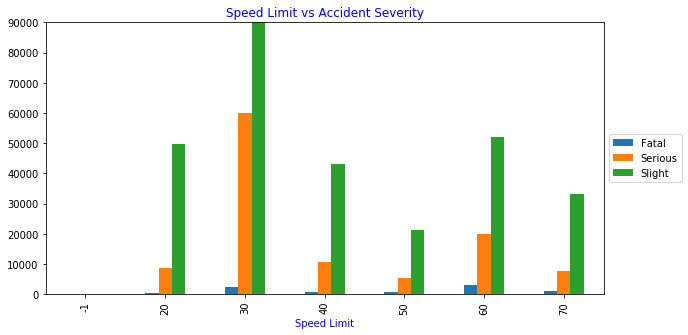

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

Panda_AccVeh_datatype = AccVeh_datatype.toPandas()

%matplotlib inline

plot_Outcome=Panda_AccVeh_datatype.pivot(index='Speed_limit', columns='Accident_Severity', values='count') \
                         .plot(kind='bar', figsize=(10,5))
plot_Outcome.set_title("Speed Limit vs Accident Severity",color="b")
plot_Outcome.set_ylim(0,90000)
plot_Outcome.set_xlabel("Speed Limit",color="b")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

In [45]:
Panda_AccVeh_datatype

,Accident_Severity,Speed_limit,count
0,Serious,-1,10
1,Slight,-1,126
2,Fatal,20,225
3,Fatal,50,685
4,Fatal,40,852
5,Fatal,70,1161
6,Fatal,30,2495
7,Fatal,60,2956
8,Serious,50,5322
9,Serious,70,7527


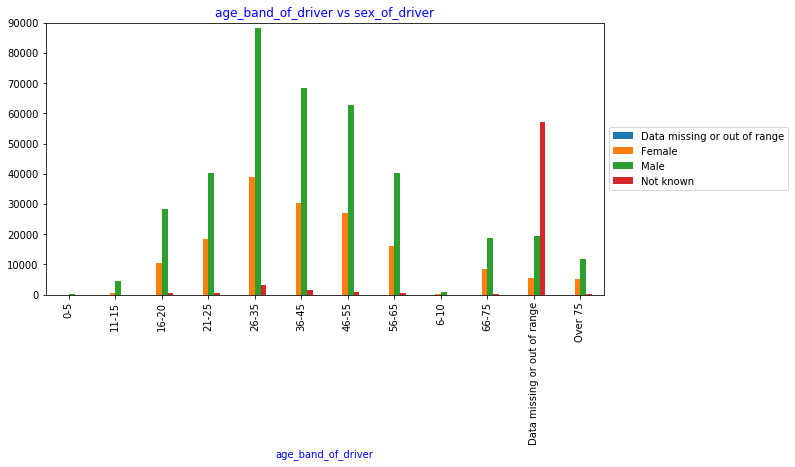

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

Panda_AccVeh_Plot = AccVeh_Plot.toPandas()

%matplotlib inline

plot_Outcome=Panda_AccVeh_Plot.pivot(index='age_band_of_driver', columns='sex_of_driver', values='count') \
                         .plot(kind='bar', figsize=(10,5))
plot_Outcome.set_title("age_band_of_driver vs sex_of_driver",color="b")
plot_Outcome.set_ylim(0,90000)
plot_Outcome.set_xlabel("age_band_of_driver",color="b")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

In [47]:
Panda_AccVeh_Plot

,sex_of_driver,age_band_of_driver,count
0,Not known,0-5,5
1,Not known,11-15,7
2,Data missing or out of range,Data missing or out of range,16
3,Female,0-5,24
4,Not known,Over 75,81
5,Male,0-5,89
6,Not known,66-75,190
7,Female,6-10,233
8,Not known,56-65,399
9,Female,11-15,483


In [48]:
# https://pixiedust.github.io/pixiedust/use.html

import pixiedust

Pixiedust database opened successfully



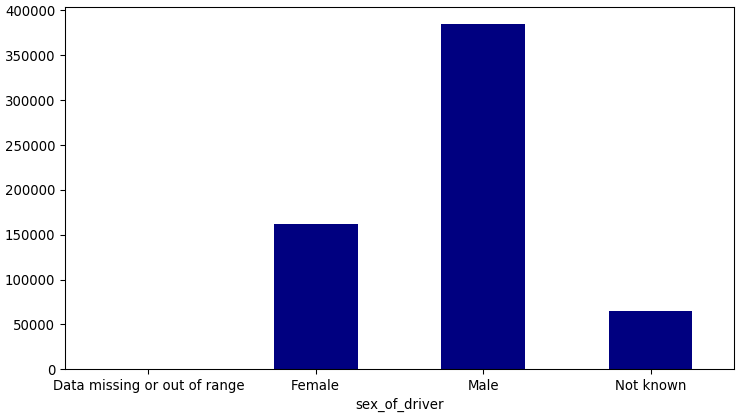

In [49]:
display(Sex_of_driver)


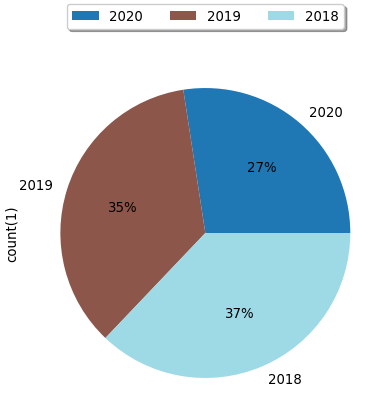

In [50]:
display(Accident_year)


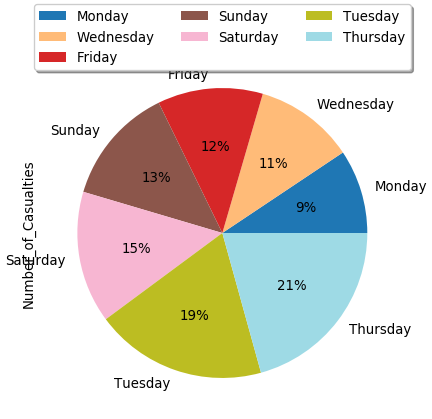

In [51]:
display(dayofweek)


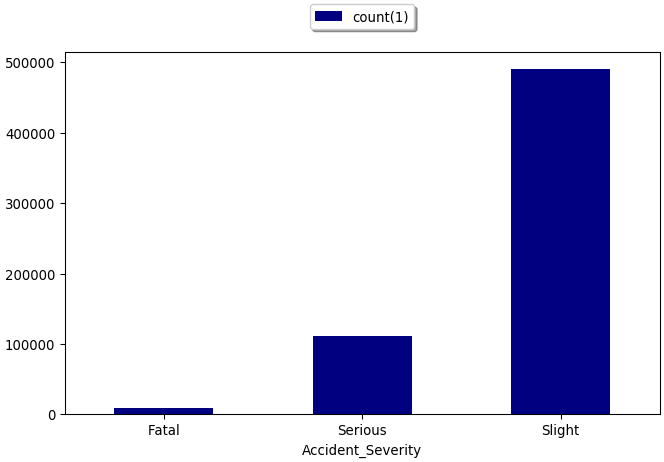

In [52]:
display(Accident_Severity)


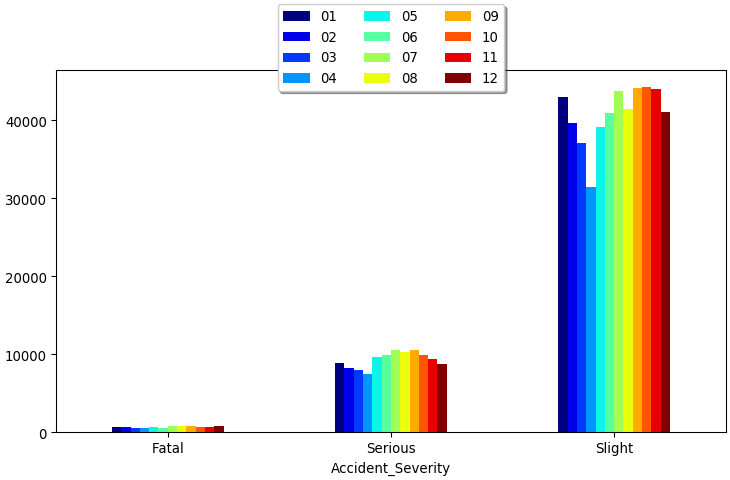

In [53]:
display(Severity)


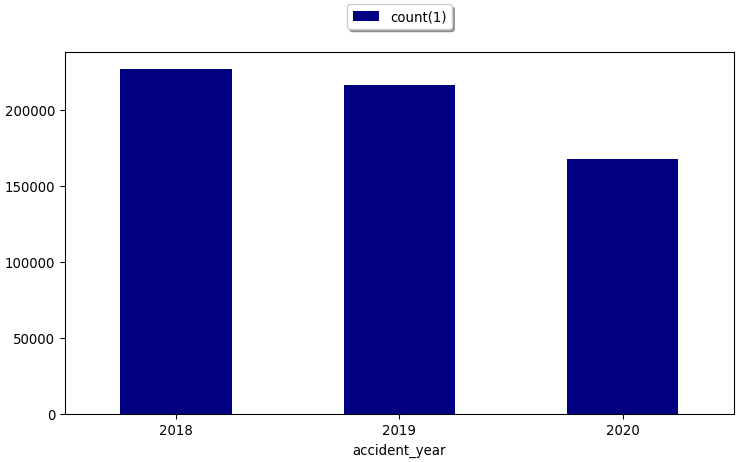

In [ ]:
display(Accident_year)


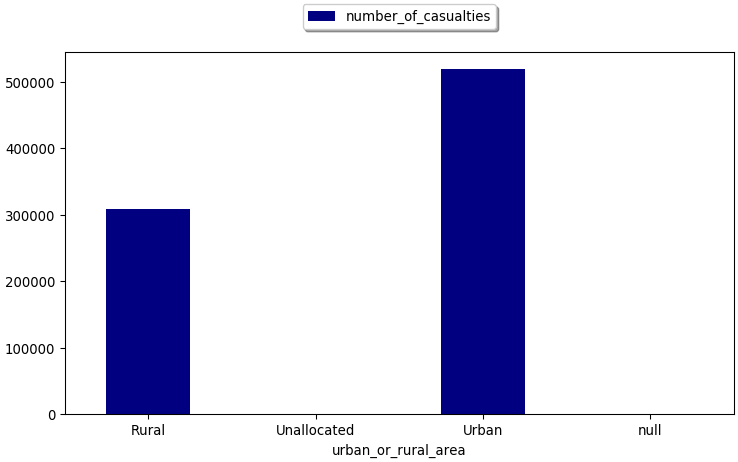

In [55]:
display(AccVeh_data)


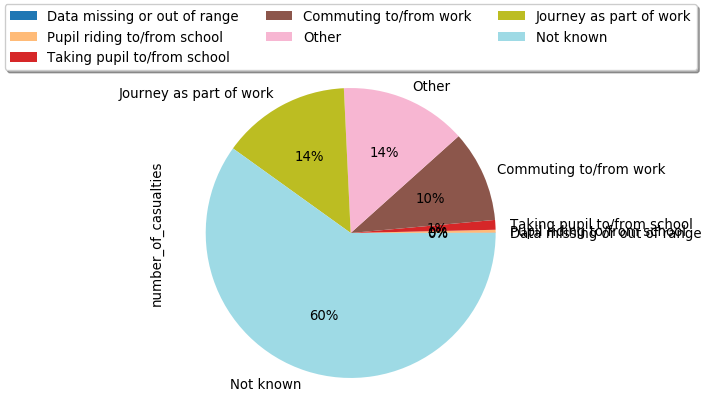

In [ ]:
display(AccVeh_data)

In [ ]:
display(AccVeh_data)


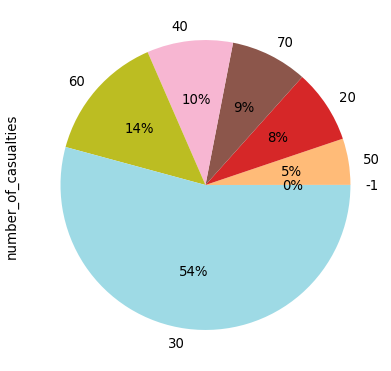

In [58]:
display(AccVeh_data)


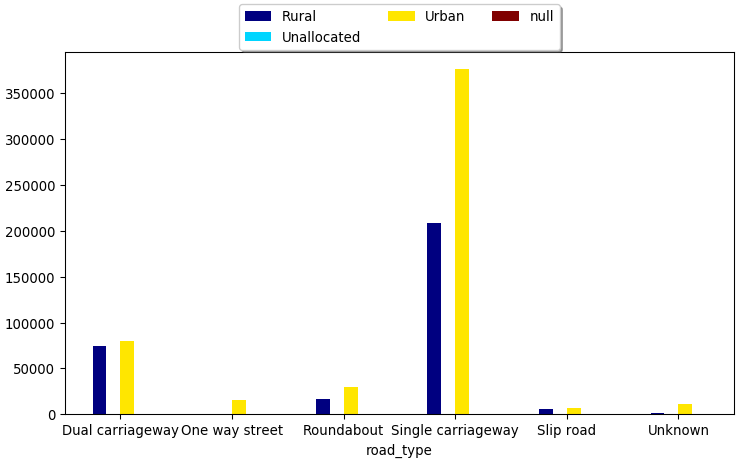

In [59]:
display(AccVeh_data)


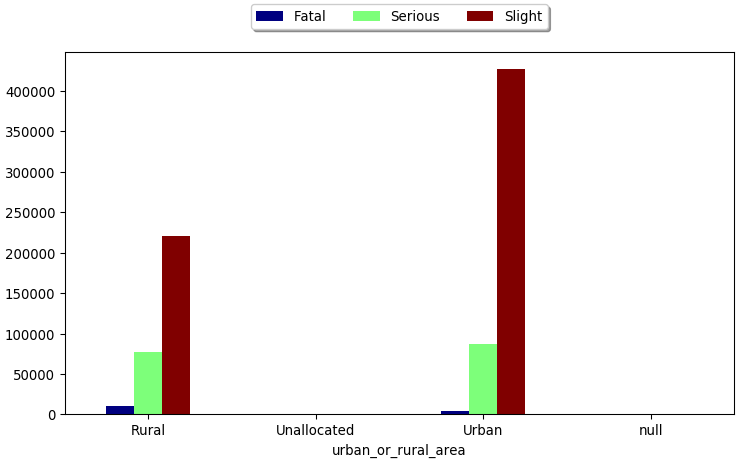

In [60]:
display(AccVeh_data)


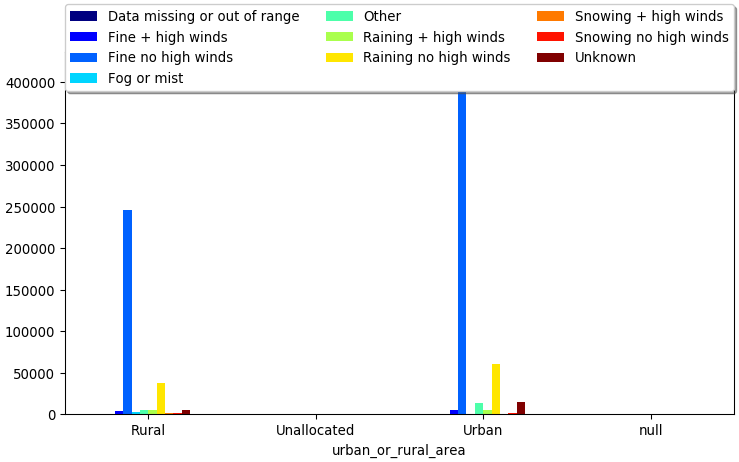

In [61]:
display(AccVeh_data)


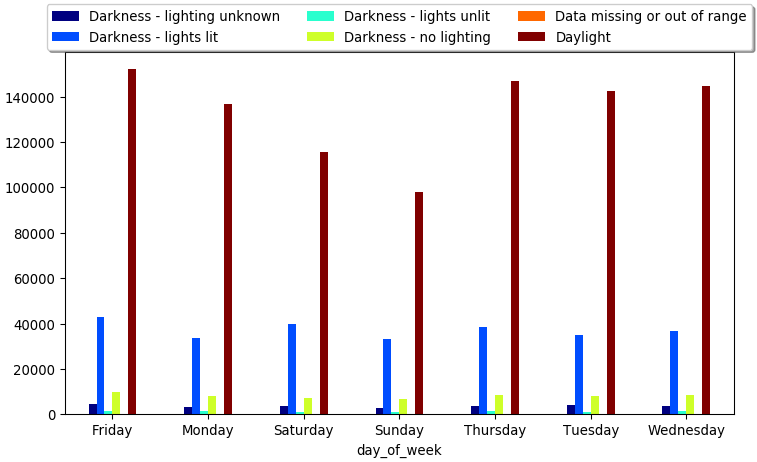

In [ ]:
display(AccVeh_data)


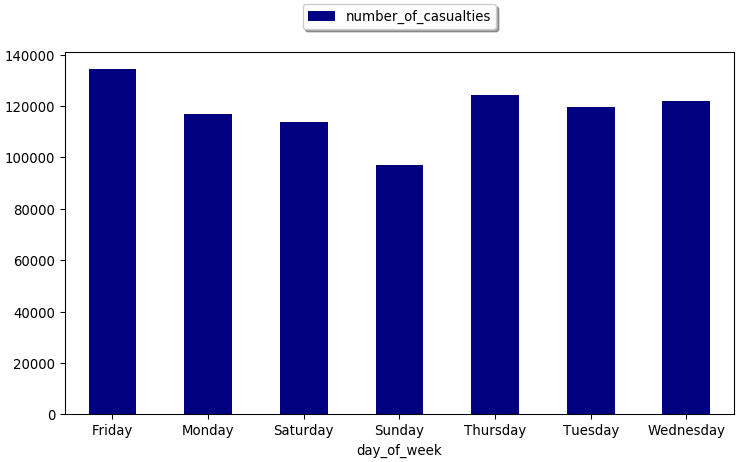

In [63]:
display(AccVeh_data)

In [64]:
AccVeh_data.select("Day_of_Week").distinct().show()

+-----------+
|Day_of_Week|
+-----------+
|  Wednesday|
|    Tuesday|
|     Friday|
|   Thursday|
|   Saturday|
|     Monday|
|     Sunday|
+-----------+



In [65]:
#Create a new DataFrame for GeographicalExplore in the UK region per year/month

AccVehGeo = sqlContext.sql("select number_of_casualties, urban_or_rural_area, \
substring(urban_or_rural_area, 0, 4) as Year, Latitude, Longitude, \
count(*) as Count from tableAccVeh group by urban_or_rural_area, \
number_of_casualties, Latitude, Longitude")


In [66]:
display(AccVehGeo)

In [67]:
display(AccVehGeo)